In [1]:
import numpy as np
import networkx as nx
from itertools import product
import os
import matplotlib.pyplot as plt
import SimpleITK as sitk
from tqdm import tqdm

In [2]:
INPUT_FILENAME = "/net/projects2/vanguard/MAMA-MIA-syn60868042/images/DUKE_001/DUKE_001_0001.nii.gz"

In [3]:
def normalize_image(image_array, min_cutoff = 0.001, max_cutoff = 0.001):
    """
    Normalize the intensity of an image array by cutting off min and max values 
    to a certain percentile and set all values above/below that percentile to 
    the new max/min. 

    Parameters
    ----------
    image_array: np.array
        3D numpy array constructed from dicom files
    min_cutoff: float
        Minimum percentile of image to keep. (0.1% = 0.001)
    max_cutoff: float
        Maximum percentile of image to keep. (0.1% = 0.001)

    Returns
    -------
    np.array
        Normalized image

    """

    # Sort image values
    sorted_array = np.sort(image_array.flatten())

    # Find %ile index and get values
    min_index = int(len(sorted_array) * min_cutoff)
    min_intensity = sorted_array[min_index]

    max_index = int(len(sorted_array) * min_cutoff) * -1
    max_intensity = sorted_array[max_index]

    # Normalize image and cutoff values
    image_array = (image_array - min_intensity) / \
        (max_intensity - min_intensity)
    image_array[image_array < 0.0] = 0.0
    image_array[image_array > 1.0] = 1.0

    return image_array

def zscore_image(image_array):
    """
    Convert intensity values in an image to zscores:
    zscore = (intensity_value - mean) / standard_deviation

    Parameters
    ----------
    image_array: np.array
        3D numpy array constructed from dicom files
    Returns
    -------
    np.array
        Image with zscores for values

    """

    image_array = (image_array - np.mean(image_array)) / np.std(image_array)

    return image_array

## Pre-processing
In order to use the `predict.py` script, the image must be
* a NumPy array (file suffix `.npy`)
* rotated from $z$, $x$, $y$ to $x$, $y$, $z$
* scaled such that the mean pixel value is 0 and the standard deviation is 1.

Here's what the original array looks like:

In [4]:
original_array = sitk.GetArrayFromImage(sitk.ReadImage(INPUT_FILENAME))
original_array.shape

(160, 448, 448)

In [5]:
np.min(original_array), np.max(original_array), np.mean(original_array), np.std(original_array)

(np.int16(0),
 np.int16(554),
 np.float64(26.94983791429169),
 np.float64(31.12284366496779))

This plots a cross-section at $z=80$, which is the first dimension in this raw image.

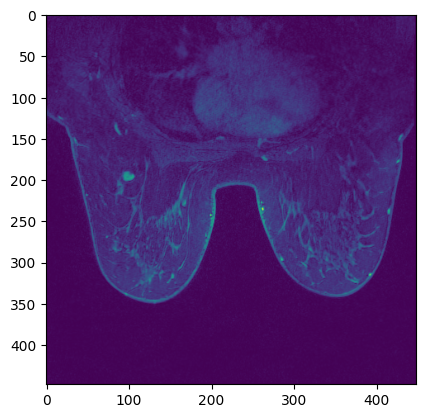

In [6]:
fig, ax = plt.subplots()

ax.imshow(original_array[80])

None

In [7]:
preprocessed_array = zscore_image(normalize_image(
    np.swapaxes(np.swapaxes(original_array, 0, 2), 0, 1)[::-1]
))
preprocessed_array.shape

(448, 448, 160)

This plots the cross-section at $z=80$, but notice that it is now the last dimension.

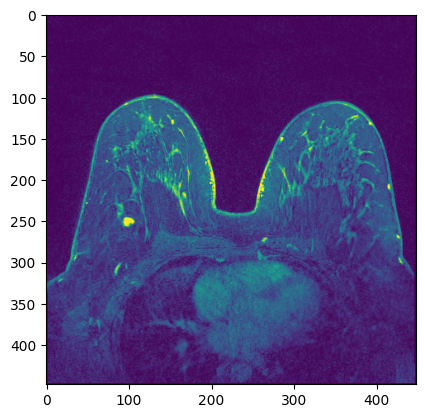

In [8]:
fig, ax = plt.subplots()

ax.imshow(preprocessed_array[:, :, 80])

None

In [9]:
def binary_image_to_graph(volume):
    """
    Convert a 3D binary image into a NetworkX graph where each '1' voxel is a node,
    connected to its 6-neighbor voxels (if they are also '1').
    Displays a progress bar while building the graph.
    """
    volume = (volume > 0).astype(np.uint8)
    z_max, y_max, x_max = volume.shape
    G = nx.Graph()

    # Define 6-connectivity
    neighbors = [
        (1, 0, 0), (-1, 0, 0),
        (0, 1, 0), (0, -1, 0),
        (0, 0, 1), (0, 0, -1)
    ]

    # Get list of vessel voxels
    vessel_voxels = np.argwhere(volume == 1)

    print(f"Building graph from {len(vessel_voxels)} voxels...")
    
    for z, y, x in tqdm(vessel_voxels, desc="Processing voxels"):
        G.add_node((z, y, x))
        for dz, dy, dx in neighbors:
            nz, ny, nx_ = z + dz, y + dy, x + dx
            if 0 <= nz < z_max and 0 <= ny < y_max and 0 <= nx_ < x_max:
                if volume[nz, ny, nx_] == 1:
                    G.add_edge((z, y, x), (nz, ny, nx_))

    print(f"✅ Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    return G

In [10]:
# Example: create a small test volume
volume = np.zeros((4, 4, 4), dtype=np.uint8)
volume[1:3, 1, 1] = 1
volume[2, 1:3, 1] = 1

G = binary_image_to_graph(volume)
print(f"Graph summary: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Building graph from 3 voxels...


Processing voxels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 27654.75it/s]

✅ Graph built with 3 nodes and 2 edges.
Graph summary: 3 nodes, 2 edges


In [11]:
volume = original_array[::2, ::2, ::2]  # downsample by factor of 2 in each dimension


In [12]:
G = binary_image_to_graph(volume)

Building graph from 3938032 voxels...


Processing voxels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3938032/3938032 [01:09<00:00, 56828.22it/s]


✅ Graph built with 3938032 nodes and 11687424 edges.


In [14]:
print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")


Nodes: 3,938,032
Edges: 11,687,424


In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_graph_3d(G, sample_size=2000):
    # Sample nodes for large graphs
    nodes = list(G.nodes())
    if len(nodes) > sample_size:
        nodes = random.sample(nodes, sample_size)
    edges = [(u, v) for u, v in G.edges() if u in nodes and v in nodes]

    xs = [n[2] for n in nodes]
    ys = [n[1] for n in nodes]
    zs = [n[0] for n in nodes]

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(xs, ys, zs, s=2, c='red', alpha=0.7)

    for u, v in edges:
        ax.plot([u[2], v[2]], [u[1], v[1]], [u[0], v[0]], c='gray', linewidth=0.3, alpha=0.3)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()

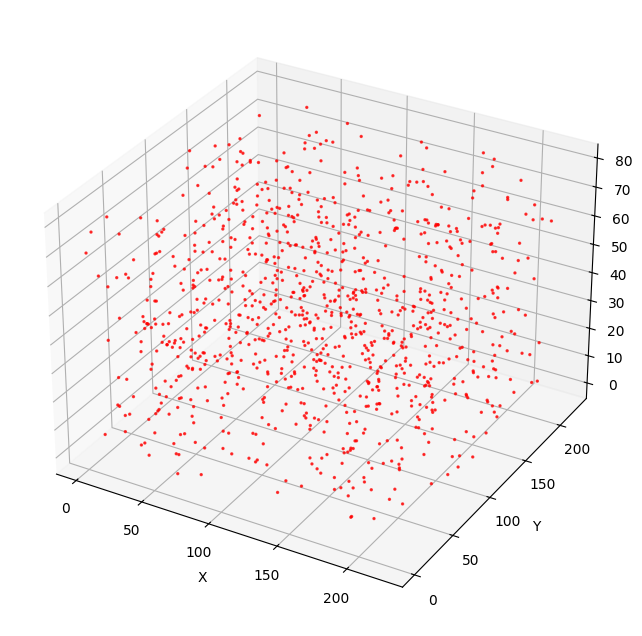

In [20]:
plot_graph_3d(G, 1000)